**Assessment#4: Machine Learning Model Comparison**
-
* **Name:** Enrico Miguel Veloso
* **Section:** 2DSA-2
* **Course:** DSA#4155 - Artificial Intelligence
* **Date:** 3/5/2026
* **Department:** College of Science
* **Institution:** University of Santo Tomas
----
* **Implementation of models and concepts:** Decision Trees, K-Nearest Neighbors, and Feature Selection
* **Dataset:** Adult Income (Census 1994)
* **Dataset Description:** The Adult Income dataset contains demographic and employment information for 32,561 individuals from the 1994 U.S. Census. In this assessment, you will implement multiple machine learning algorithms to predict whether a person's annual income exceeds $50,000, comparing traditional econometric approaches (LPM, Logistic Regression) with machine learning methods (K-Nearest Neighbors, Decision Trees).

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 
import statsmodels.formula.api as smf
import random
import time
import warnings
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, validation_curve
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, mean_squared_error, mean_absolute_error, r2_score)
from sklearn.inspection import permutation_importance
from scipy.spatial.distance import pdist, squareform
from scipy.stats import entropy
warnings.filterwarnings('ignore')

#Set plotting style:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

#Set seed:
random.seed(16)

**1. Data Preparation and Exploratory Data Analysis**
- 

**A.) Data Loading and Preprocessing:**

In [2]:
#Load the dataset:
df = fetch_openml('adult', version = 2, as_frame = True)
df = df.frame
df.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
#Check dataframe shape:
df_shape = df.shape

In [4]:
print("Total number of rows:", df_shape[0])
print("Total number of columns:", df_shape[1])

Total number of rows: 48842
Total number of columns: 15


In [5]:
#Dataset descriptive statistics:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
#Check for null values:
num_null_col = df.isnull().sum()
num_null_row = df.isnull().any(axis=1).sum()
num_not_null_row = df.notnull().all(axis=1).sum()

In [7]:
print(num_null_col)
print("=" * 60)
print("Total number of rows that have no null value:", num_not_null_row)
print("Total number of rows that atleast 1 null value:", num_null_row)

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
class                0
dtype: int64
Total number of rows that have no null value: 45222
Total number of rows that atleast 1 null value: 3620


In [8]:
#Handling missing values:
df_clean = df.dropna()
num_null_col = df_clean.isnull().sum()
num_null_row = df_clean.isnull().any(axis=1).sum()
num_not_null_row = df_clean.notnull().all(axis=1).sum()
total_rows = df.shape[0]
remaining_rows = df_clean.shape[0]
data_loss_percent = ((total_rows - remaining_rows) / total_rows) * 100

In [9]:
print(num_null_col)
print("=" * 60)
print("Total number of rows that have no null value:", num_not_null_row)
print("Total number of rows that atleast 1 null value:", num_null_row)
print("Data loss after dropping all rows with null values:", f"{data_loss_percent:.2f}","%")

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
class             0
dtype: int64
Total number of rows that have no null value: 45222
Total number of rows that atleast 1 null value: 0
Data loss after dropping all rows with null values: 7.41 %


In [10]:
#Create target variable:
df_clean['high_income'] = (df_clean['class'] == '>50K').astype(int)
df_clean = df_clean.drop('class', axis = 1)
df_clean.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,high_income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,0


**B.) Exploratory Data Analysis:**

In [11]:
#Group all columns that are categorical:
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_cols = " | ".join(categorical_cols)

In [12]:
print("Categorical columns:", categorical_cols)

Categorical columns: workclass | education | marital-status | occupation | relationship | race | sex | native-country


In [13]:
#Convert categorical to dummy variables:
dum_WC = pd.get_dummies(df_clean['workclass'], prefix = "WC", drop_first = True).astype(int)
dum_EDUC = pd.get_dummies(df_clean['education'], prefix = "EDUC", drop_first = True).astype(int)
dum_MS = pd.get_dummies(df_clean['marital-status'], prefix = "MS", drop_first = True).astype(int)
dum_OCC = pd.get_dummies(df_clean['occupation'], prefix = "OCC", drop_first = True).astype(int)
dum_REL = pd.get_dummies(df_clean['relationship'], prefix = "REL", drop_first = True).astype(int)
dum_RCE = pd.get_dummies(df_clean['race'], prefix = "RCE", drop_first = True).astype(int)
dum_SX = pd.get_dummies(df_clean['sex'], prefix = "SX", drop_first = True).astype(int)
dum_NC = pd.get_dummies(df_clean['native-country'], prefix = "NC", drop_first = True).astype(int)
df_clean = pd.concat([df_clean, dum_WC, dum_EDUC, dum_MS, dum_OCC, dum_REL, dum_RCE, dum_SX, dum_NC], axis = 1)
df_clean = df_clean.dropna()
df_clean.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,...,NC_Portugal,NC_Puerto-Rico,NC_Scotland,NC_South,NC_Taiwan,NC_Thailand,NC_Trinadad&Tobago,NC_United-States,NC_Vietnam,NC_Yugoslavia
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,...,0,0,0,0,0,0,0,1,0,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,...,0,0,0,0,0,0,0,1,0,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,...,0,0,0,0,0,0,0,1,0,0
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,...,0,0,0,0,0,0,0,1,0,0
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,...,0,0,0,0,0,0,0,1,0,0


In [14]:
#Check if there are null values after creation of dummy variables:
print("Check if there are null values after creation of dummy variables")
print("=" * 64)
print(df_clean.isnull().sum())

Check if there are null values after creation of dummy variables
age                   0
workclass             0
fnlwgt                0
education             0
education-num         0
                     ..
NC_Thailand           0
NC_Trinadad&Tobago    0
NC_United-States      0
NC_Vietnam            0
NC_Yugoslavia         0
Length: 106, dtype: int64


In [15]:
#Drop non-numerical features or columns:
df_clean = df_clean.select_dtypes(include = ['number'])
numerical_cols = " | ".join(df_clean.columns.tolist())
num_cols = len(df_clean.columns.tolist())

In [16]:
print("Total number of columns or features:", num_cols)
print("=" * 60)
print(numerical_cols)

Total number of columns or features: 98
age | fnlwgt | education-num | capital-gain | capital-loss | hours-per-week | high_income | WC_Local-gov | WC_Never-worked | WC_Private | WC_Self-emp-inc | WC_Self-emp-not-inc | WC_State-gov | WC_Without-pay | EDUC_11th | EDUC_12th | EDUC_1st-4th | EDUC_5th-6th | EDUC_7th-8th | EDUC_9th | EDUC_Assoc-acdm | EDUC_Assoc-voc | EDUC_Bachelors | EDUC_Doctorate | EDUC_HS-grad | EDUC_Masters | EDUC_Preschool | EDUC_Prof-school | EDUC_Some-college | MS_Married-AF-spouse | MS_Married-civ-spouse | MS_Married-spouse-absent | MS_Never-married | MS_Separated | MS_Widowed | OCC_Armed-Forces | OCC_Craft-repair | OCC_Exec-managerial | OCC_Farming-fishing | OCC_Handlers-cleaners | OCC_Machine-op-inspct | OCC_Other-service | OCC_Priv-house-serv | OCC_Prof-specialty | OCC_Protective-serv | OCC_Sales | OCC_Tech-support | OCC_Transport-moving | REL_Not-in-family | REL_Other-relative | REL_Own-child | REL_Unmarried | REL_Wife | RCE_Asian-Pac-Islander | RCE_Black | RCE_

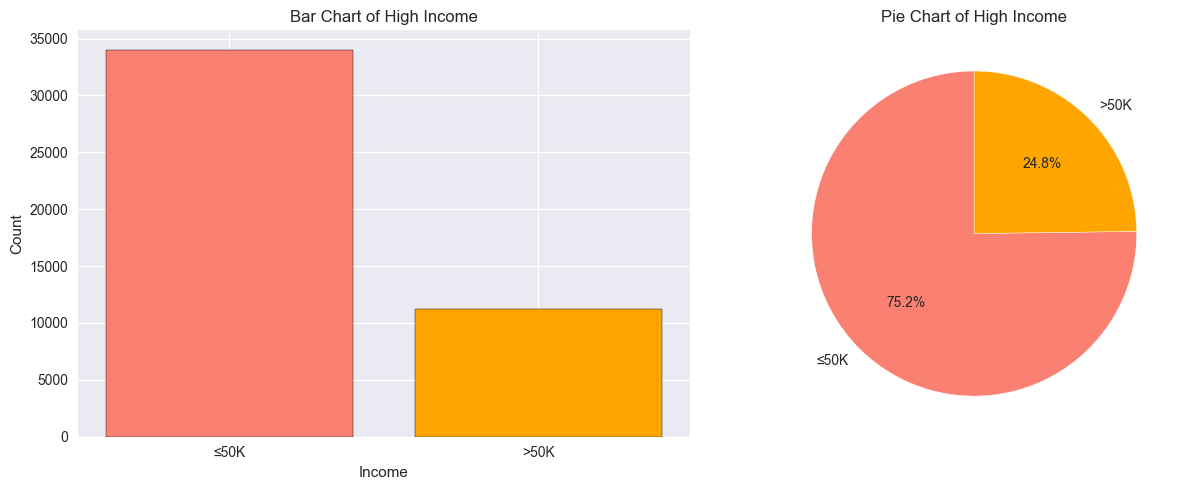

In [17]:
#Visualizations showing the distribution of the target variable:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#Bar chart (counts):
counts = df_clean['high_income'].value_counts().sort_index()
axes[0].bar(['≤50K', '>50K'], counts, color=['salmon', 'orange'], edgecolor='black')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Count')
axes[0].set_title('Bar Chart of High Income')

#Pie chart (percentages):
df_clean['high_income'].value_counts().plot.pie(autopct='%1.1f%%', labels=['≤50K', '>50K'], colors=['salmon', 'orange'], ax=axes[1], startangle=90)
axes[1].set_title('Pie Chart of High Income')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

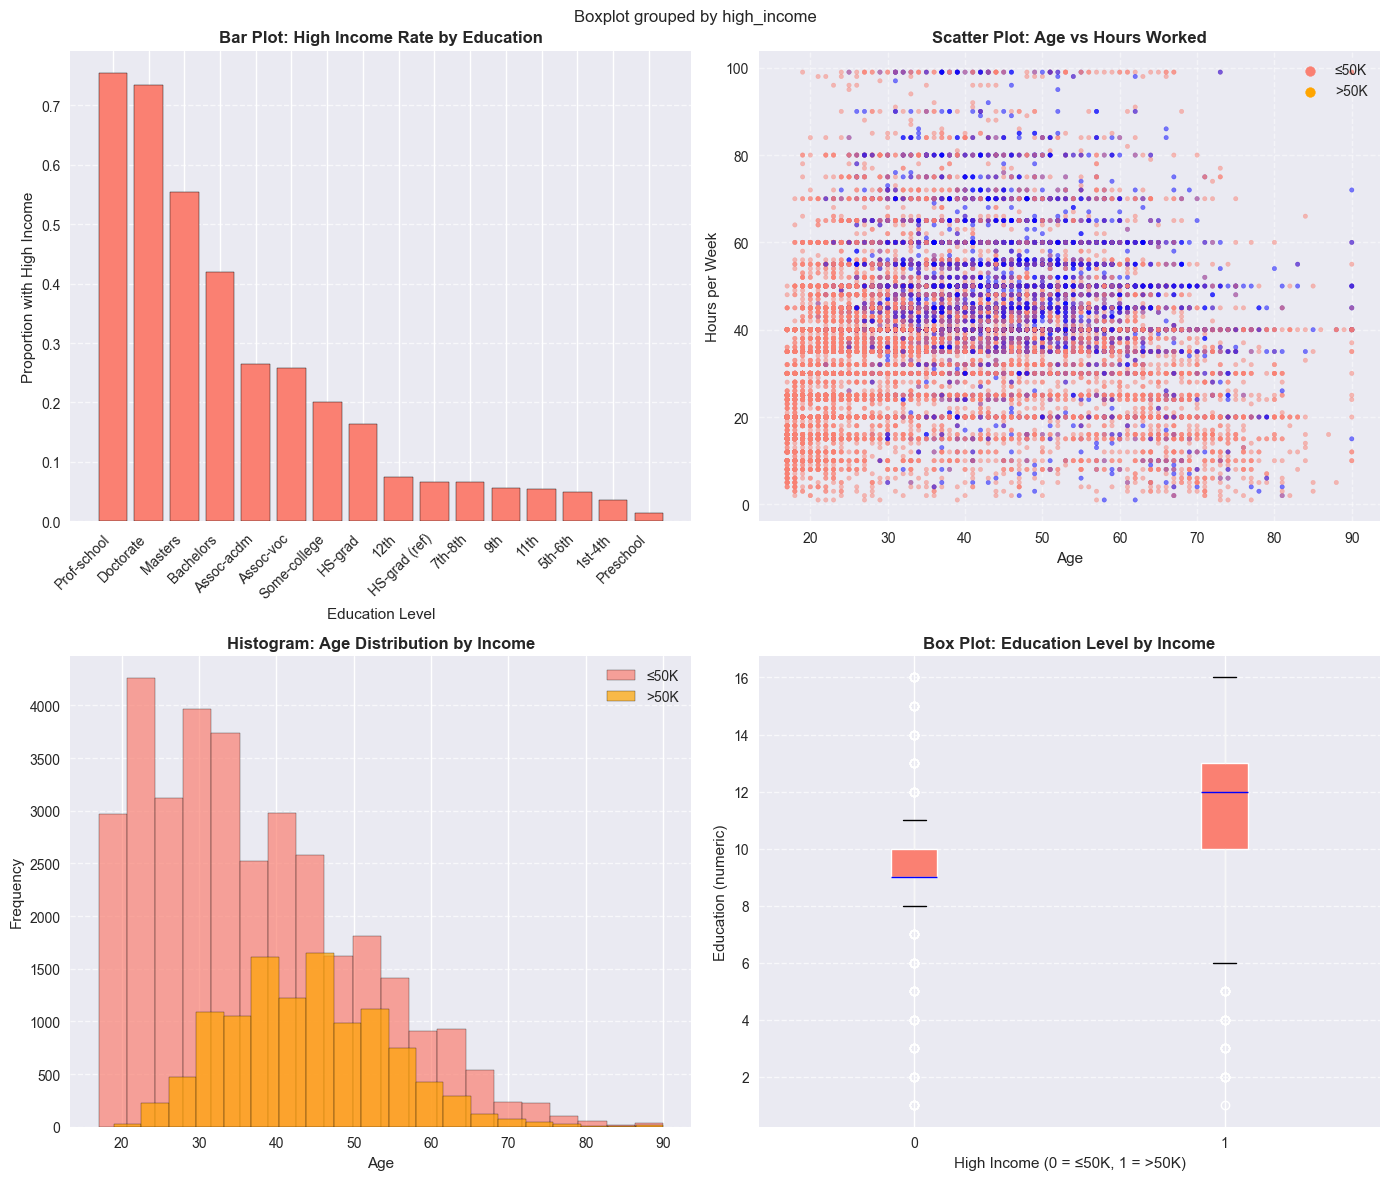

In [18]:
#Generate at least 3 informative plots exploring relationships between features and target:

#Prepare data for education bar plot (using dummy columns from your encoding):
educ_dummies = [col for col in df_clean.columns if col.startswith('EDUC_')]
educ_means = []
for col in educ_dummies:
    mean_val = df_clean.loc[df_clean[col] == 1, 'high_income'].mean()
    cat_name = col.replace('EDUC_', '')
    educ_means.append((cat_name, mean_val))

#Reference category (all dummies = 0) – label it appropriately:
ref_mask = (df_clean[educ_dummies] == 0).all(axis=1)
ref_mean = df_clean.loc[ref_mask, 'high_income'].mean()
educ_means.append(('HS-grad (ref)', ref_mean))
educ_df = pd.DataFrame(educ_means, columns=['Education', 'Proportion_High_Income'])
educ_df = educ_df.sort_values('Proportion_High_Income', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Relationships Between Features and Income', fontsize=16, fontweight='bold')

#Bar plot: Education vs High Income Rate;
ax = axes[0, 0]
bars = ax.bar(educ_df['Education'], educ_df['Proportion_High_Income'], color='salmon', edgecolor='black')
ax.set_xlabel('Education Level')
ax.set_ylabel('Proportion with High Income')
ax.set_title('Bar Plot: High Income Rate by Education', fontweight='bold')
ax.set_xticklabels(educ_df['Education'], rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.7)

#Scatter plot: Age vs Hours per Week:
ax = axes[0, 1]
colors = df_clean['high_income'].map({0: 'salmon', 1: 'blue'})
ax.scatter(df_clean['age'], df_clean['hours-per-week'], c=colors, alpha=0.5, s=10)
ax.set_xlabel('Age')
ax.set_ylabel('Hours per Week')
ax.set_title('Scatter Plot: Age vs Hours Worked', fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
ax.scatter([], [], color='salmon', label='≤50K')
ax.scatter([], [], color='orange', label='>50K')
ax.legend()

#Histogram: Age distribution by income group:
ax = axes[1, 0]
df_clean[df_clean['high_income'] == 0]['age'].hist(ax=ax, bins=20, alpha=0.7, label='≤50K', color='salmon', edgecolor='black')
df_clean[df_clean['high_income'] == 1]['age'].hist(ax=ax, bins=20, alpha=0.7, label='>50K', color='orange', edgecolor='black')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
ax.set_title('Histogram: Age Distribution by Income', fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

#Box plot: Education-num by income group:
ax = axes[1, 1]
df_clean.boxplot(column='education-num', by='high_income', ax=ax, patch_artist=True, boxprops=dict(facecolor='salmon'), medianprops=dict(color='blue'))
ax.set_title('Box Plot: Education Level by Income', fontweight='bold')
ax.set_xlabel('High Income (0 = ≤50K, 1 = >50K)')
ax.set_ylabel('Education (numeric)')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

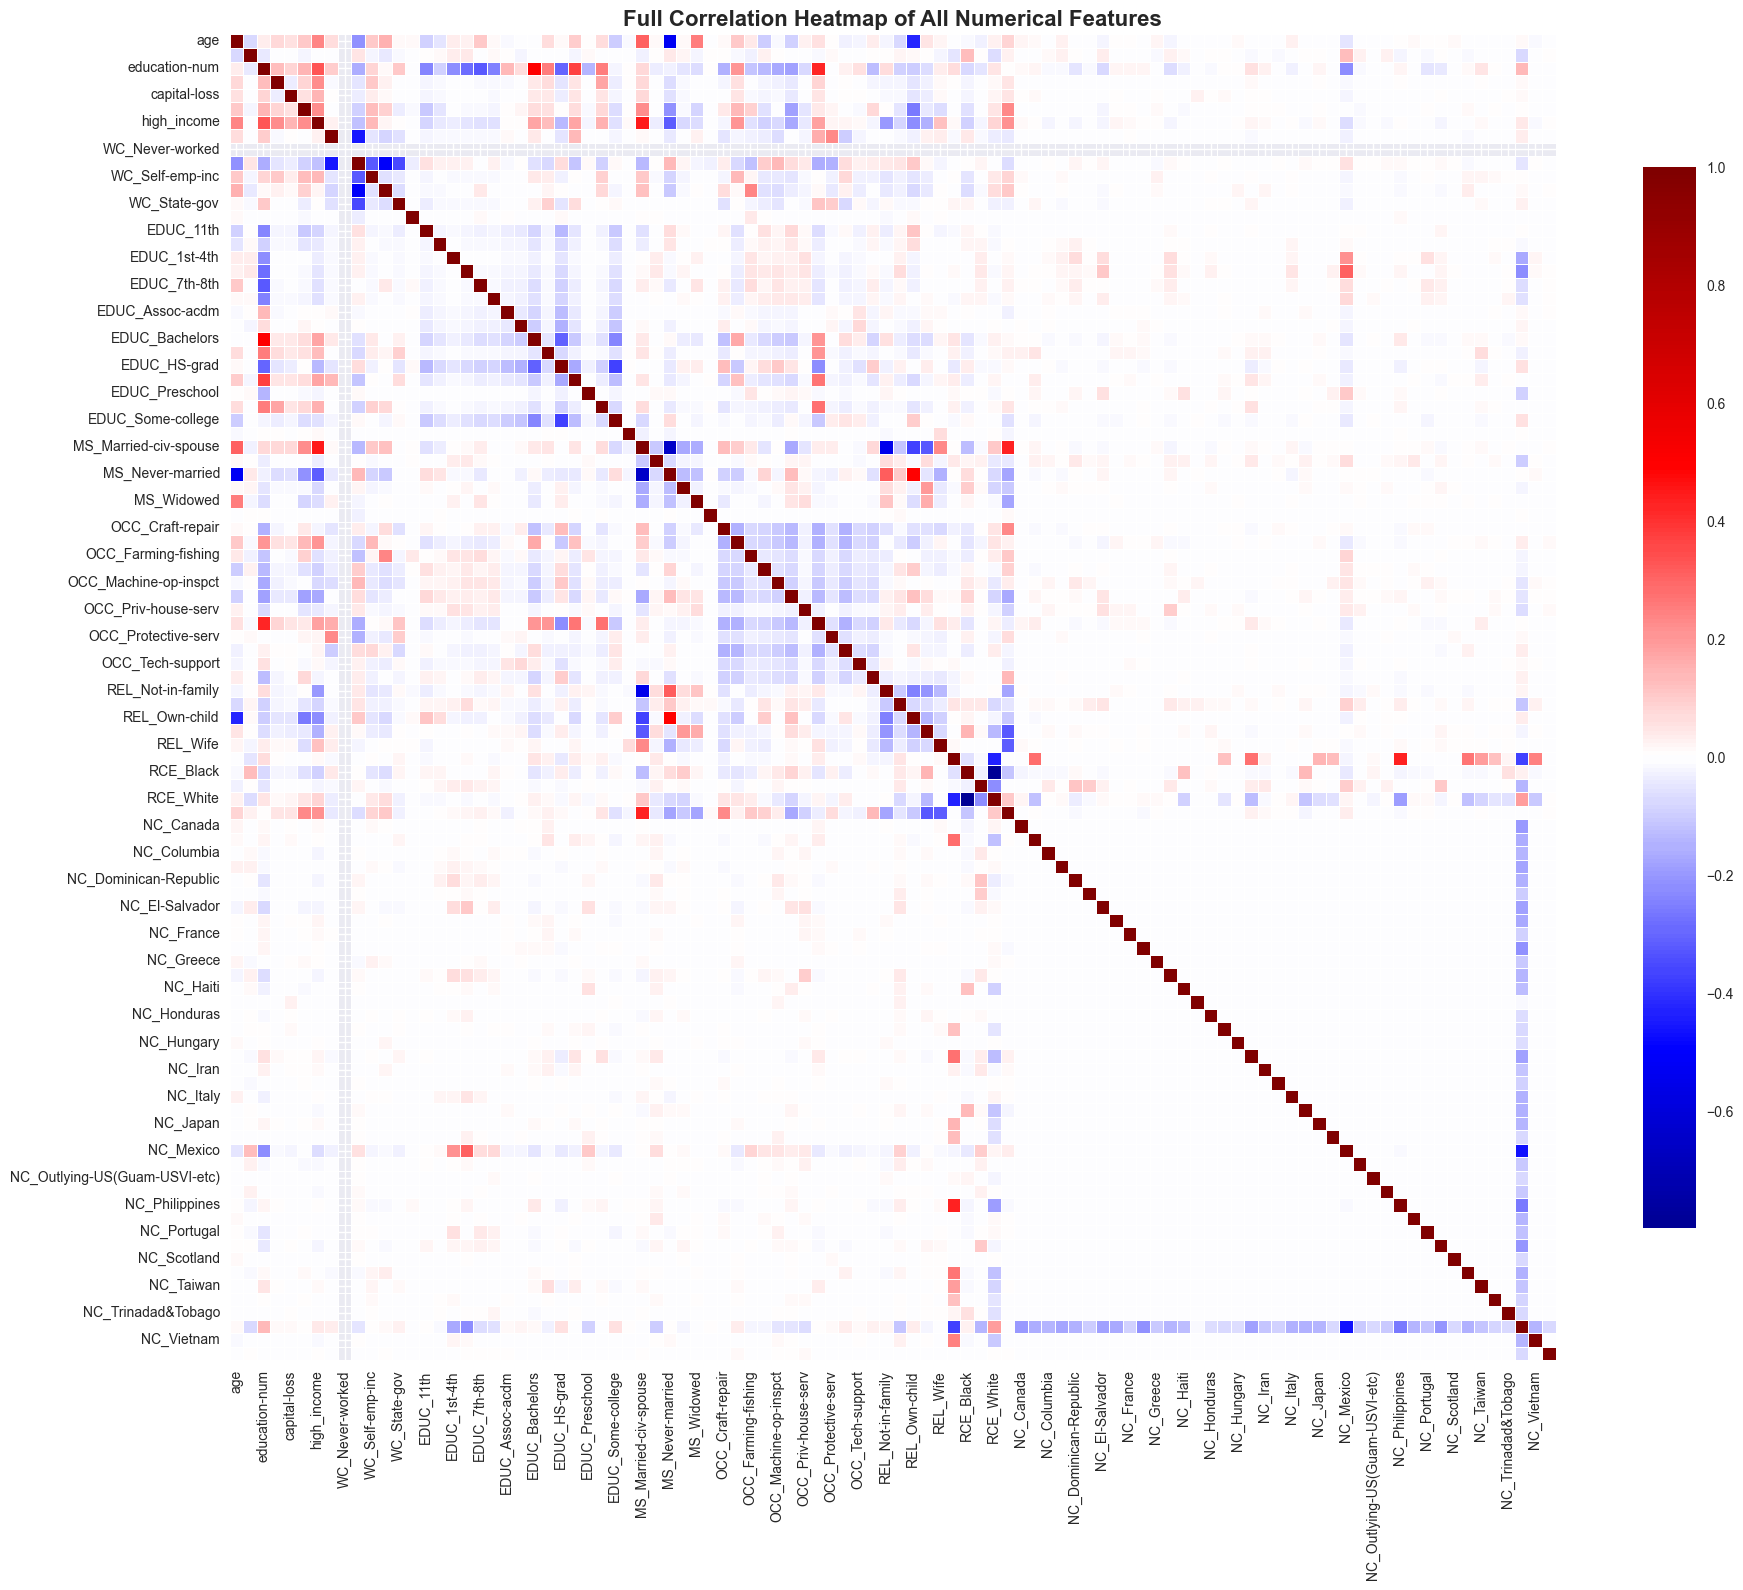

In [19]:
#Correlation heatmap for numerical features:
plt.figure(figsize=(20, 16))
corr_full = df_clean.corr()
sns.heatmap(corr_full, annot=False, cmap='seismic', center=0,square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Full Correlation Heatmap of All Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

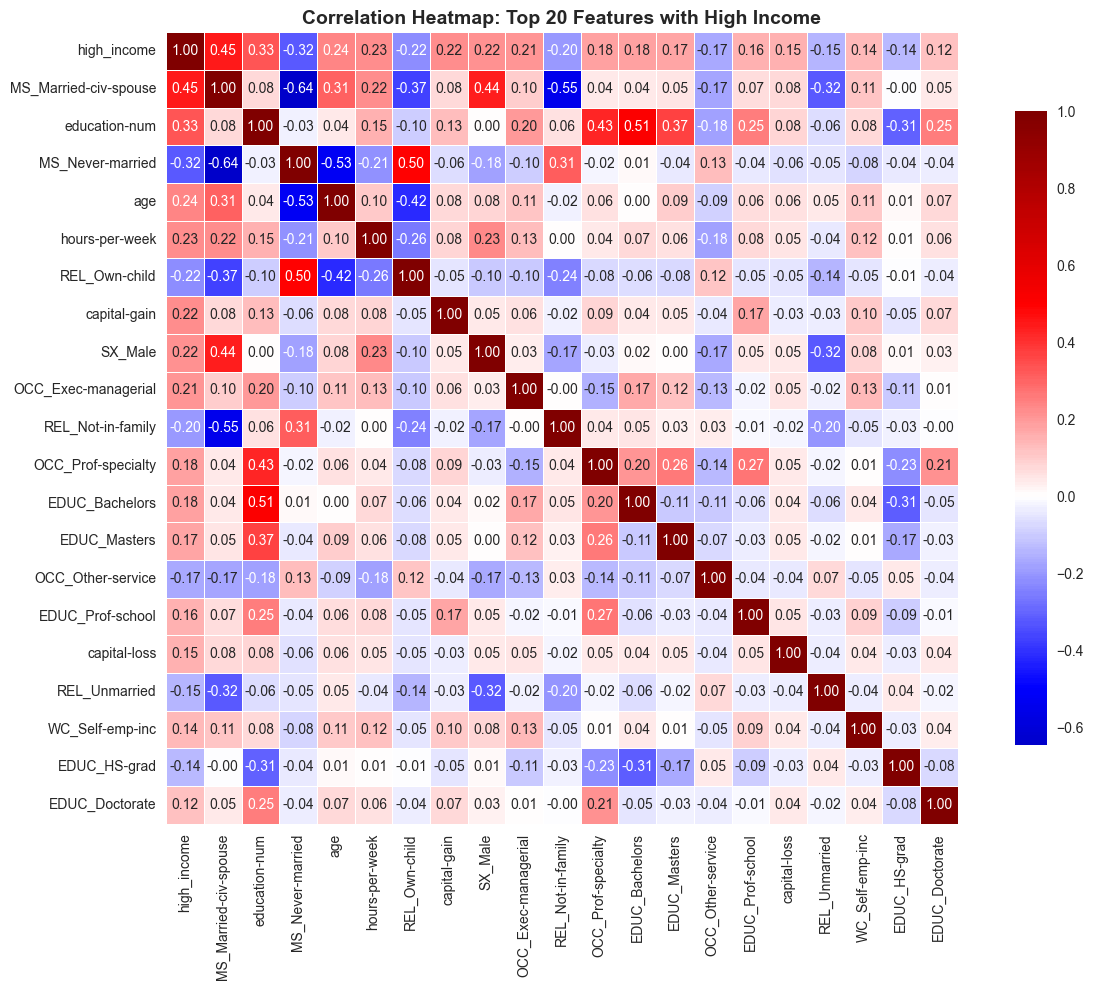

In [20]:
#Focused heatmap: top 20 features most correlated with high_income:
corr_target = df_clean.corr()['high_income'].abs().sort_values(ascending=False)
top_features = corr_target.head(21).index
plt.figure(figsize=(13, 10))
sns.heatmap(df_clean[top_features].corr(), annot=True, fmt='.2f', cmap='seismic', center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap: Top 20 Features with High Income', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**2. Train-Test Split and Feature Selection**
-

**A.) Train-Test Split:**

In [21]:
#Prepare your feature (X) and target variable (y) for Decision Trees application:
X = df_clean.drop('high_income', axis = 1)
y = df_clean['high_income']

In [22]:
#Split dataframe to test and train sets for Decision Trees application:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [23]:
#Display the shapes of training and testing sets:
print("Training set shape:")
print("=" * 40)
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print("\nTesting set shape:")
print("=" * 40)
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Training set shape:
X_train: (36177, 97)
y_train: (36177,)

Testing set shape:
X_test: (9045, 97)
y_test: (9045,)


**B.) Decision Tree for Feature Selection:**

In [24]:
#Train a Decision Tree classifier on the training set using all features:
dt_selector = DecisionTreeClassifier(random_state=42)
dt_selector.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [25]:
#Extract feature importance scores:
importances = dt_selector.feature_importances_
feature_names = X_train.columns

In [26]:
#Create a DataFrame for feature importance:
feat_imp_df = pd.DataFrame({'Feature': feature_names,'Importance': importances}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

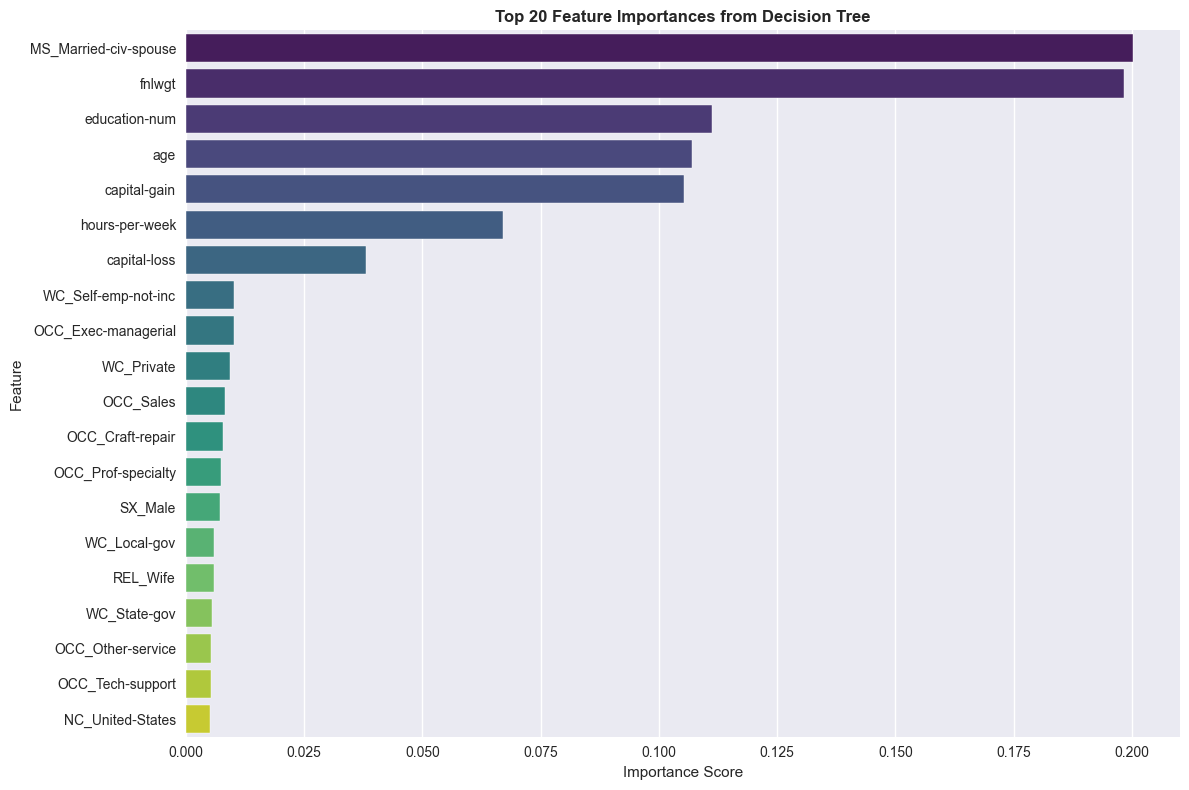

In [27]:
#Create a visualization (bar plot) showing feature importance scores:

#Show top 20 for clarity (you can adjust or show all by removing head(20)):
plt.figure(figsize=(12, 8))
top_n = 20
sns.barplot(data=feat_imp_df.head(top_n), x='Importance', y='Feature', palette='viridis')
plt.title(f'Top {top_n} Feature Importances from Decision Tree', fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [28]:
#Select the top 12 most important features:
top_12_features = feat_imp_df.head(12)['Feature'].tolist()
print("Top 12 selected features:")
print("=" * 60)
print(" | ".join(top_12_features))

Top 12 selected features:
MS_Married-civ-spouse | fnlwgt | education-num | age | capital-gain | hours-per-week | capital-loss | WC_Self-emp-not-inc | OCC_Exec-managerial | WC_Private | OCC_Sales | OCC_Craft-repair


In [29]:
#Create a table showing: Feature name, Importance score, Selected (Yes/No):
feat_imp_df['Selected'] = feat_imp_df['Feature'].isin(top_12_features).map({True: 'Yes', False: 'No'})

In [30]:
#Display the full table (or just a preview):
print("Feature Importance Table (all features):")
print("=" * 60)
print(feat_imp_df.to_string(index=False))

Feature Importance Table (all features):
                      Feature  Importance Selected
        MS_Married-civ-spouse    0.200170      Yes
                       fnlwgt    0.198372      Yes
                education-num    0.111147      Yes
                          age    0.107072      Yes
                 capital-gain    0.105384      Yes
               hours-per-week    0.067045      Yes
                 capital-loss    0.038142      Yes
          WC_Self-emp-not-inc    0.010269      Yes
          OCC_Exec-managerial    0.010255      Yes
                   WC_Private    0.009309      Yes
                    OCC_Sales    0.008194      Yes
             OCC_Craft-repair    0.007870      Yes
           OCC_Prof-specialty    0.007351       No
                      SX_Male    0.007146       No
                 WC_Local-gov    0.006017       No
                     REL_Wife    0.005881       No
                 WC_State-gov    0.005504       No
            OCC_Other-service    0.005314

In [31]:
#Optionally, display only top 20 for cleaner view:
print("Top 20 features with selection status:")
print("=" * 60)
print(feat_imp_df.head(20).to_string(index=False))

Top 20 features with selection status:
              Feature  Importance Selected
MS_Married-civ-spouse    0.200170      Yes
               fnlwgt    0.198372      Yes
        education-num    0.111147      Yes
                  age    0.107072      Yes
         capital-gain    0.105384      Yes
       hours-per-week    0.067045      Yes
         capital-loss    0.038142      Yes
  WC_Self-emp-not-inc    0.010269      Yes
  OCC_Exec-managerial    0.010255      Yes
           WC_Private    0.009309      Yes
            OCC_Sales    0.008194      Yes
     OCC_Craft-repair    0.007870      Yes
   OCC_Prof-specialty    0.007351       No
              SX_Male    0.007146       No
         WC_Local-gov    0.006017       No
             REL_Wife    0.005881       No
         WC_State-gov    0.005504       No
    OCC_Other-service    0.005314       No
     OCC_Tech-support    0.005311       No
     NC_United-States    0.005083       No


In [32]:
#Prepare the reduced feature set (X_train_selected, X_test_selected) for model training:
X_train_selected = X_train[top_12_features]
X_test_selected = X_test[top_12_features]

In [33]:
print(f"Reduced feature set shape:")
print("=" * 40)
print(f"X_train_selected: {X_train_selected.shape}")
print(f"X_test_selected: {X_test_selected.shape}")

Reduced feature set shape:
X_train_selected: (36177, 12)
X_test_selected: (9045, 12)


**3. Four-Model Training and Comparison**
-

**A.) Model Training:**

**1.) Linear Probability Model (LPM) - Linear Regression:**

In [34]:
#Add constant to feature set:
X_train_sm = sm.add_constant(X_train_selected)
X_test_sm = sm.add_constant(X_test_selected)

In [35]:
#Model summary of LPM based from the selected features derived from the Desicion Trees:
lpm = sm.OLS(y_train, X_train_sm).fit()
print(lpm.summary())

                            OLS Regression Results                            
Dep. Variable:            high_income   R-squared:                       0.350
Model:                            OLS   Adj. R-squared:                  0.350
Method:                 Least Squares   F-statistic:                     1623.
Date:                Thu, 05 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:33:29   Log-Likelihood:                -13157.
No. Observations:               36177   AIC:                         2.634e+04
Df Residuals:                   36164   BIC:                         2.645e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -0.57

**2.) Logistics Regression:**

In [36]:
#Model summary of LRM based from the selected features derived from the Desicion Trees:
lrm = sm.Logit(y_train, X_train_sm).fit()
print(lrm.summary())

Optimization terminated successfully.
         Current function value: 0.337472
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:            high_income   No. Observations:                36177
Model:                          Logit   Df Residuals:                    36164
Method:                           MLE   Df Model:                           12
Date:                Thu, 05 Mar 2026   Pseudo R-squ.:                  0.3973
Time:                        23:33:30   Log-Likelihood:                -12209.
converged:                       True   LL-Null:                       -20257.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -9.2876      0.146    -63.634      0.000      -9.574      -9.

**3.) K-Nearest Neighbors (K=9):**

In [37]:
#K-Nearest Neighbors (K=9) - using sklearn (requires scaling):
scaler = StandardScaler()
X_train_selected_scaled = scaler.fit_transform(X_train_selected)
X_test_selected_scaled = scaler.transform(X_test_selected)

knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train_selected_scaled, y_train)
y_pred_knn = knn.predict(X_test_selected_scaled)

**4.) Decision Tree:**

In [38]:
#Decision Tree - using sklearn (default parameters):
dt2 = DecisionTreeClassifier(random_state=42)
dt2.fit(X_train_selected, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [39]:
#Display training accuracy from the Descision Tree:
train_acc = dt2.score(X_train_selected, y_train)
print(f"Training Accuracy: {train_acc:.4f}")

Training Accuracy: 0.9998


In [40]:
#Feature importance:
feat_imp_dt2 = pd.DataFrame({'Feature': X_train_selected.columns,'Importance': dt2.feature_importances_}).sort_values('Importance', ascending=False)
print("Feature Importances (from Decision Tree on selected features):")
print("=" * 62)
print(feat_imp_dt2.to_string(index=False))

Feature Importances (from Decision Tree on selected features):
              Feature  Importance
               fnlwgt    0.262490
MS_Married-civ-spouse    0.200229
        education-num    0.127321
                  age    0.122887
         capital-gain    0.107788
       hours-per-week    0.074963
         capital-loss    0.040360
           WC_Private    0.017101
     OCC_Craft-repair    0.013513
            OCC_Sales    0.012618
  OCC_Exec-managerial    0.011119
  WC_Self-emp-not-inc    0.009610


**B.) Coefficient Analysis Table:**

In [41]:
#Extract coefficients from statsmodels (excluding the constant term):
lpm_coef = lpm.params[1:]        
logit_coef = lrm.params[1:]      

In [42]:
#Create comparison DataFrame:
coef_comparison = pd.DataFrame({'Feature': X_train_selected.columns, 'LPM β': lpm_coef.values, 'Logistic β': logit_coef.values})

In [43]:
#Compute difference (LPM - Logistic):
coef_comparison['Difference (LPM - Logit)'] = coef_comparison['LPM β'] - coef_comparison['Logistic β']

In [44]:
#Display full table (unrounded for precision):
print("Full coefficient comparison:")
print("=" * 75)
print(coef_comparison.to_string(index=False))

Full coefficient comparison:
              Feature         LPM β    Logistic β  Difference (LPM - Logit)
MS_Married-civ-spouse  3.135936e-01  2.483270e+00             -2.169677e+00
               fnlwgt  9.978167e-08  7.857064e-07             -6.859248e-07
        education-num  4.104225e-02  3.486649e-01             -3.076227e-01
                  age  2.906474e-03  2.862847e-02             -2.572199e-02
         capital-gain  8.412307e-06  3.120151e-04             -3.036028e-04
       hours-per-week  2.753845e-03  2.947528e-02             -2.672144e-02
         capital-loss  9.626178e-05  6.645934e-04             -5.683316e-04
  WC_Self-emp-not-inc -9.278784e-02 -7.017862e-01              6.089984e-01
  OCC_Exec-managerial  1.241868e-01  7.631232e-01             -6.389364e-01
           WC_Private -1.777416e-02 -9.889366e-02              8.111950e-02
            OCC_Sales  4.149558e-02  2.614324e-01             -2.199369e-01
     OCC_Craft-repair -4.811490e-03  1.658656e-01          

**4. Decision Tree Visualization**
-

**A.) Decision Tree Graph:**

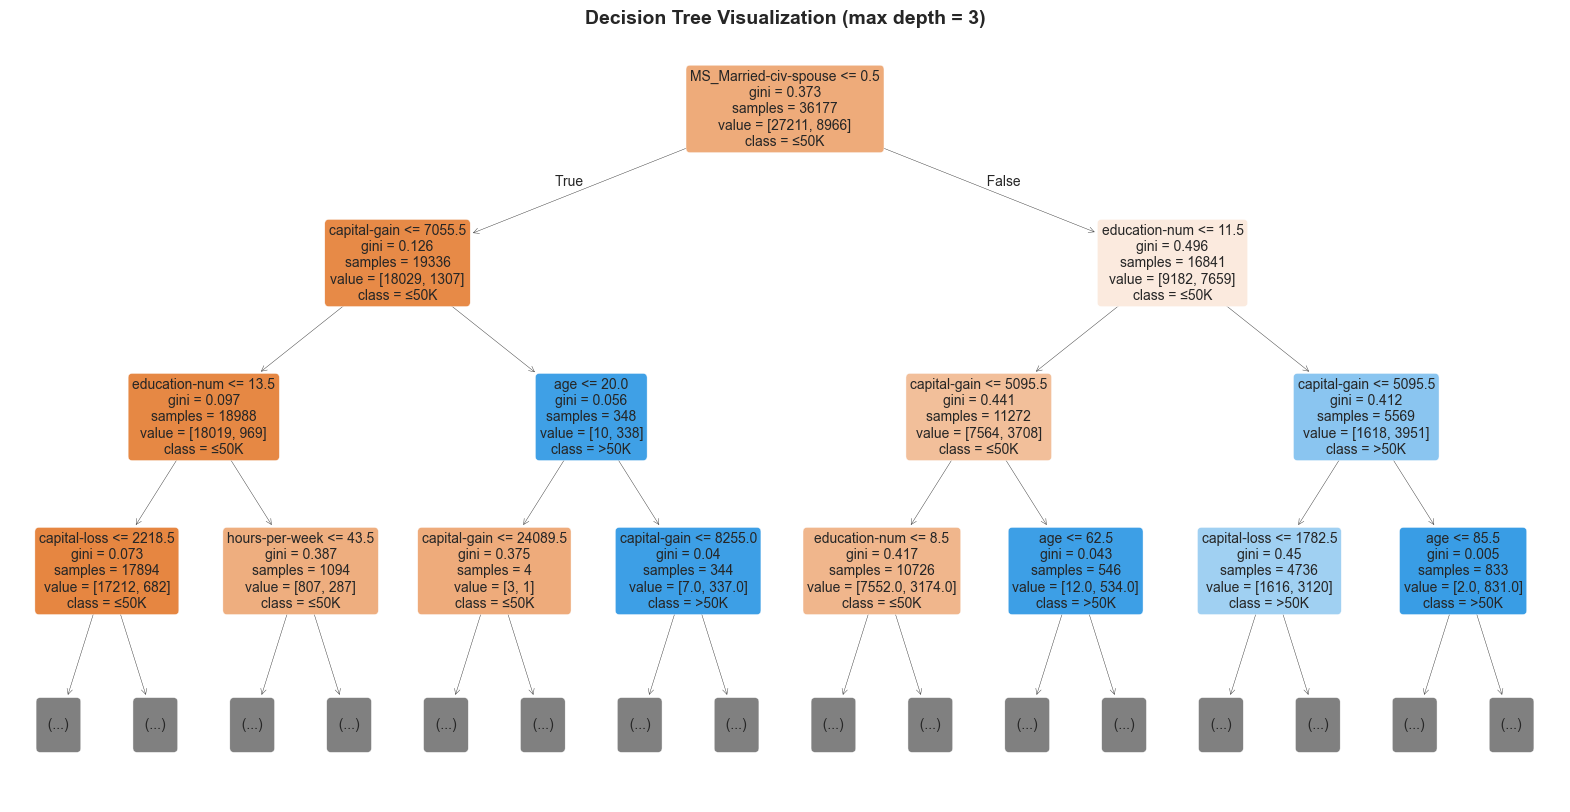

In [45]:
#Visualize the trained Decision Tree (max_depth=3 for readability):
plt.figure(figsize=(20, 10))
plot_tree(dt2, feature_names=X_train_selected.columns, class_names=['≤50K', '>50K'], filled=True, rounded=True, max_depth=3, fontsize=10)
plt.title("Decision Tree Visualization (max depth = 3)", fontsize=14, fontweight='bold')
plt.show()

**5. Model Performance Evaluation**
-

**A.) Confusion Matrices:**

In [46]:
#Generate predictions on the test set and use 0.5 as the classification threshold:
y_pred_lpm_class = (lpm.predict(X_test_sm) > 0.5).astype(int)
y_pred_logit_class = (lrm.predict(X_test_sm) > 0.5).astype(int)
y_pred_knn = knn.predict(X_test_selected_scaled)
y_pred_dt2 = dt2.predict(X_test_selected)

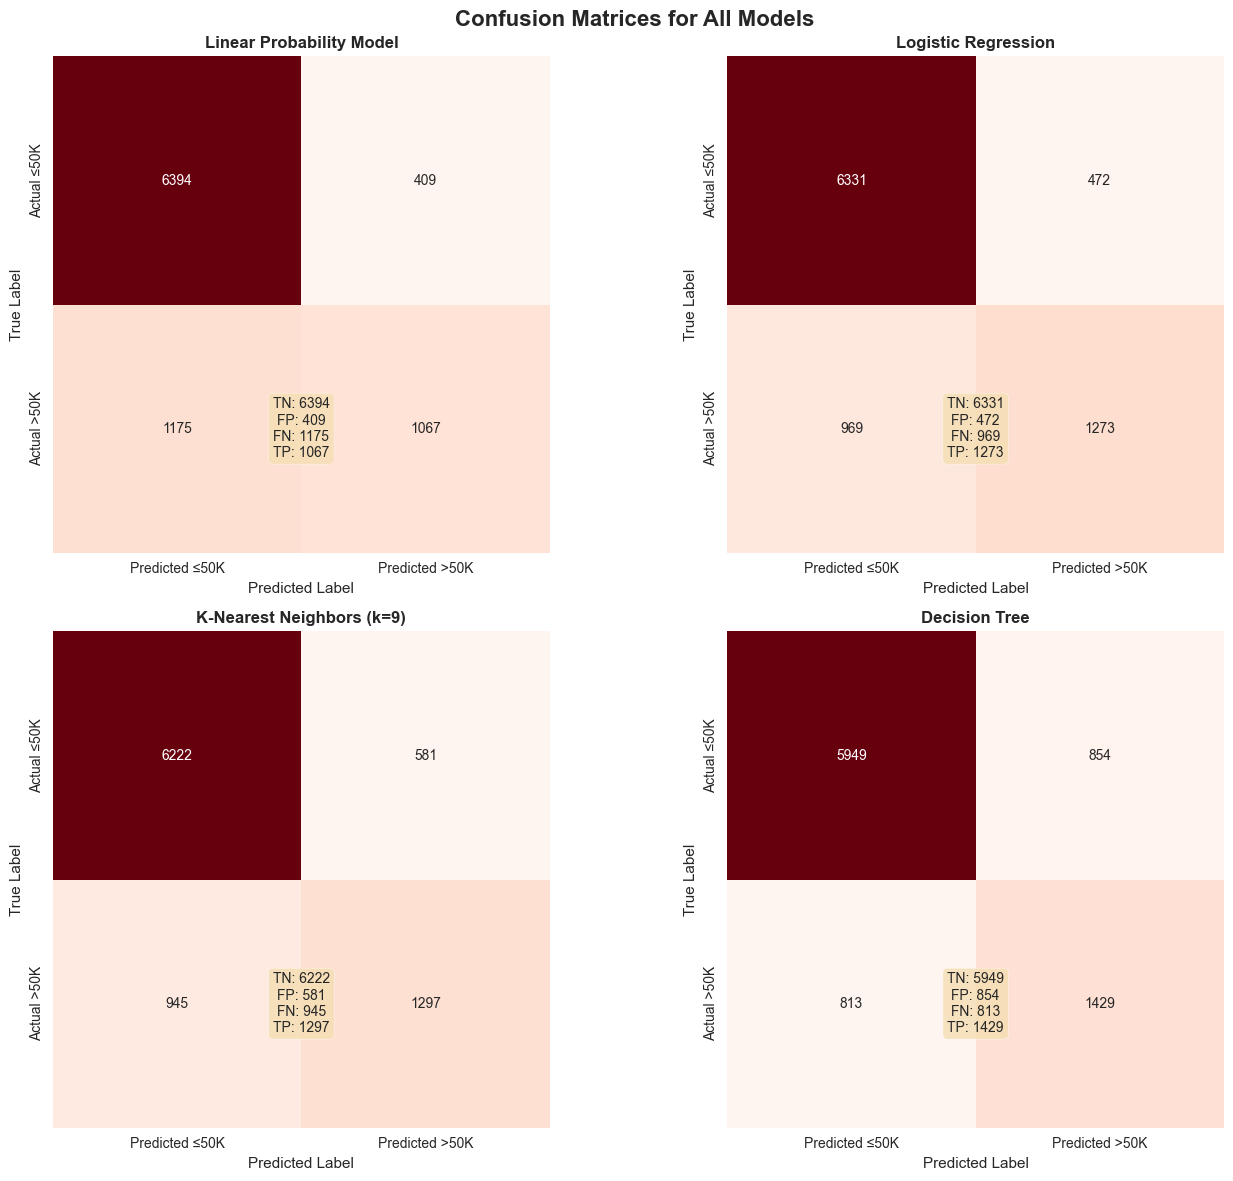

In [47]:
#Display confusion matrix with proper labels (TP, FP, TN, FN):
predictions = {'Linear Probability Model': y_pred_lpm_class, 'Logistic Regression': y_pred_logit_class,'K-Nearest Neighbors (k=9)': y_pred_knn, 'Decision Tree': y_pred_dt2}

#Set up the 2x2 subplot grid:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Confusion Matrices for All Models', fontsize=16, fontweight='bold')

#Loop through models and plot heatmaps:
for ax, (model_name, y_pred) in zip(axes.flatten(), predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    # Create heatmap:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Predicted ≤50K', 'Predicted >50K'], yticklabels=['Actual ≤50K', 'Actual >50K'], cbar=False, ax=ax, square=True)
    
    # Add labels and title:
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    
    #Add text annotations for TP, FP, FN, TN:
    ax.text(0.5, 0.25, f'TN: {tn}\nFP: {fp}\nFN: {fn}\nTP: {tp}', transform=ax.transAxes, fontsize=10, verticalalignment='center', horizontalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

In [48]:
#Calculate and report Type I and Type II error rates for each model

#Dictionary to store error rates:
error_rates = {}

#Function to compute error rates:
def compute_error_rates(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    total_neg = tn + fp
    total_pos = fn + tp
    type1 = fp / total_neg if total_neg > 0 else 0
    type2 = fn / total_pos if total_pos > 0 else 0
    return type1, type2, (tn, fp, fn, tp)

#Compute for each model:
models = {'Linear Probability Model': y_pred_lpm_class, 'Logistic Regression': y_pred_logit_class, 'K-Nearest Neighbors (k=9)': y_pred_knn, 'Decision Tree': y_pred_dt2}

for name, y_pred in models.items():
    t1, t2, (tn, fp, fn, tp) = compute_error_rates(y_test, y_pred)
    error_rates[name] = {
        'Type I (False Positive)': f'{t1:.4f} ({fp}/{tn+fp})',
        'Type II (False Negative)': f'{t2:.4f} ({fn}/{fn+tp})',
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp}

#Display as DataFrame:
error_df = pd.DataFrame(error_rates).T
print("=" * 74)
print("TYPE I AND TYPE II ERROR RATES")
print("=" * 74)
print(error_df[['Type I (False Positive)', 'Type II (False Negative)']].to_string())
print("=" * 74)
print("Confusion Matrix Components (TN, FP, FN, TP):")
print(error_df[['TN', 'FP', 'FN', 'TP']].to_string())

TYPE I AND TYPE II ERROR RATES
                          Type I (False Positive) Type II (False Negative)
Linear Probability Model        0.0601 (409/6803)       0.5241 (1175/2242)
Logistic Regression             0.0694 (472/6803)        0.4322 (969/2242)
K-Nearest Neighbors (k=9)       0.0854 (581/6803)        0.4215 (945/2242)
Decision Tree                   0.1255 (854/6803)        0.3626 (813/2242)
Confusion Matrix Components (TN, FP, FN, TP):
                             TN   FP    FN    TP
Linear Probability Model   6394  409  1175  1067
Logistic Regression        6331  472   969  1273
K-Nearest Neighbors (k=9)  6222  581   945  1297
Decision Tree              5949  854   813  1429


**B.) Classification Metrics Comparison:**

In [49]:
#Collect predictions (ensure they are defined from previous cells):
predictions = {'Linear Probability Model': y_pred_lpm_class, 'Logistic Regression': y_pred_logit_class, 'K-Nearest Neighbors (k=9)': y_pred_knn, 'Decision Tree': y_pred_dt2}

#Calculate metrics for each model:
metrics_list = []
for model_name, y_pred in predictions.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    metrics_list.append({'Model': model_name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})

#Create DataFrame:
metrics_df = pd.DataFrame(metrics_list)

#Round to 4 decimal places for readability:
metrics_df = metrics_df.round(4)

print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON TABLE")
print("="*70)
print(metrics_df.to_string(index=False))


MODEL PERFORMANCE COMPARISON TABLE
                    Model  Accuracy  Precision  Recall  F1-Score
 Linear Probability Model    0.8249     0.7229  0.4759    0.5740
      Logistic Regression    0.8407     0.7295  0.5678    0.6386
K-Nearest Neighbors (k=9)    0.8313     0.6906  0.5785    0.6296
            Decision Tree    0.8157     0.6259  0.6374    0.6316
